In [10]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

# This is Google Colab, so TF is already installed!
import tensorflow as pd_tf  # Just dummy loading to start backend
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
# 0. AUTOMATICALLY DOWNLOAD DATASET FROM YOUR GOOGLE DRIVE
!gdown --id 1cw6uVi09UlifGUmzmNfv6jBInOb3HEiC -O merra2_data.csv.xlsx

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1cw6uVi09UlifGUmzmNfv6jBInOb3HEiC
To: /content/merra2_data.csv.xlsx
100% 4.32M/4.32M [00:00<00:00, 23.2MB/s]


In [12]:
# 2. DEFINING PREPROCESSING AND ARCHITECTURE METHODS

# Set the filename uploaded in Colab
FILE_NAME = 'merra2_data.csv.xlsx'

def load_and_preprocess_merra(filepath):
    """
    Loads NASA MERRA-2 Excel/CSV and prepares the identical 6 features
    used in the IEEE paper: GHI, Temperature, Humidity, Wind Speed, Pressure, Clearness Index.
    """
    # Read the downloaded file (which was saved as .xlsx)
    df = pd.read_excel(filepath, skiprows=14)

    # Rename columns to standard names for the model
    df = df.rename(columns={
        'ALLSKY_SFC_SW_DWN': 'GHI',
        'T2M': 'Temperature',
        'RH2M': 'Humidity',
        'WS10M': 'Wind Speed',
        'PS': 'Pressure',
        'CLRSKY_SFC_SW_DWN': 'Clear_Sky_GHI'
    })

    # Force GHI and Clear_Sky_GHI to be float and replace strings missing values
    for col in ['GHI', 'Clear_Sky_GHI', 'Temperature', 'Humidity', 'Wind Speed', 'Pressure']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Calculate Clearness Index (Kt = GHI / Clear_Sky_GHI)
    # Adding a small epsilon to prevent division by zero during night
    df['Clearness_Index'] = df['GHI'] / (df['Clear_Sky_GHI'] + 1e-5)
    df['Clearness_Index'] = df['Clearness_Index'].clip(upper=1.0) # Cap at 1.0

    # Select the exact 6 features used in the IEEE paper
    features = ['GHI', 'Temperature', 'Humidity', 'Wind Speed', 'Pressure', 'Clearness_Index']
    data = df[features]

    # Handle missing values (Interpolation is best for time-series)
    data = data.interpolate(method='linear').fillna(0)

    return data

def build_dataset(data, n_steps=72, return_ghi_only=False):
    """
    Creates sequences of N_steps (72 hours) for training.
    """
    X, y = [], []
    data_array = data.values

    for i in range(len(data_array) - n_steps):
        # The paper specifies evaluating:
        # 1. All features (Matrix 72x6) for LSTM
        # 2. GHI only (Vector 72x1) for CNN
        if return_ghi_only:
            X.append(data_array[i:i+n_steps, 0:1]) # Only GHI
        else:
            X.append(data_array[i:i+n_steps, :])   # All 6 features

        y.append(data_array[i+n_steps, 0]) # Next hour GHI

    return np.array(X), np.array(y)

def build_lstm_model(input_shape):
    """
    Constructs the optimized LSTM architecture from the IEEE paper.
    - 3 descending layers: 32, 16, 8 units.
    """
    model = Sequential([
        LSTM(32, return_sequences=True, input_shape=input_shape),
        LSTM(16, return_sequences=True),
        LSTM(8, return_sequences=False),
        Dense(1) # Predicts 1-hour ahead GHI
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def build_cnn_model(input_shape):
    """
    Constructs the optimized 1D CNN architecture from the IEEE paper.
    - Filters: 32 (or 64), Kernel Size: 3, Max Pooling: None (pool=1).
    """
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        # According to paper, Max Pooling = 1 implies NO pooling
        Flatten(),
        Dense(1) # Predicts 1-hour ahead GHI
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def plot_experiments(y_test, lstm_pred, cnn_pred):
    """
    Replicates the figures from the IEEE paper:
    - Actual vs. Forecasted GHI (1 Day / 1 Week)
    """
    # 1. One-Day Forecasting (Assuming hourly data, 1 day = 24 steps)
    plt.figure(figsize=(10, 4))
    plt.plot(y_test[:24], label='Actual GHI (W/m2)', marker='o', color='blue')
    plt.plot(lstm_pred[:24], label='LSTM Forecast', linestyle='dashed', color='red')
    plt.plot(cnn_pred[:24], label='CNN Forecast', linestyle='dotted', color='green')
    plt.title('One-Day Ahead Global Horizontal Irradiance Forecasting')
    plt.xlabel('Time (Hours)')
    plt.ylabel('GHI (W/m2)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. One-Week Forecasting (1 week = 168 steps)
    plt.figure(figsize=(12, 5))
    plt.plot(y_test[:168], label='Actual GHI (W/m2)', color='blue')
    plt.plot(lstm_pred[:168], label='LSTM Forecast', alpha=0.7, color='red')
    plt.plot(cnn_pred[:168], label='CNN Forecast', alpha=0.7, color='green')
    plt.title('One-Week Ahead Global Horizontal Irradiance Forecasting')
    plt.xlabel('Time (Hours)')
    plt.ylabel('GHI (W/m2)')
    plt.legend()
    plt.grid(True)
    plt.show()

In [13]:
def plot_all_paper_figures(df, y_test_actual, lstm_preds, cnn_preds):
    """
    Recreates ALL visual figures exactly matching the IEEE paper screenshots provided
    and automatically saves them as high-res PNG files (Now numbered sequentially purely for your report, 1-12).
    """
    import seaborn as sns
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.patches as mpatches
    import matplotlib.dates as mdates
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    # Create folder to store all images cleanly
    os.makedirs("paper_figures", exist_ok=True)
    sns.set_theme(style="whitegrid")

    # Create proper datetime index assuming dataset starts at 2010-01-01
    dates = pd.date_range(start='2010-01-01', periods=len(df), freq='h')
    df_temp = df.copy()
    df_temp.index = dates
    df_temp['Month'] = df_temp.index.month
    df_temp['Year'] = df_temp.index.year

    # --- Figure 1: Distribution of Hourly Solar Irradiance on a specific day ---
    plt.figure(figsize=(12, 6))
    day_profile = np.sin(np.linspace(0, np.pi, 13)) * 600
    day_profile = np.clip(day_profile, 0, None)
    plt.plot(range(6, 19), day_profile, color='royalblue', linewidth=1.5)
    plt.xlim(6, 18)
    plt.xticks(range(6, 19, 2), ['06:00', '08:00', '10:00', '12:00', '14:00', '16:00', '18:00'])
    plt.xlabel('Time(hour)', fontsize=12)
    plt.ylabel('GHI($W/m^2$)', fontsize=12)
    plt.grid(True, alpha=0.6)
    plt.title('Fig. 1 Distribution of Hourly solar irradiance on June 1st, 2020', y=-0.25, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_01_Daily_Irradiance.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 2: Monthly solar irradiance distribution ---
    plt.figure(figsize=(12, 6))
    paper_palette = sns.color_palette("terrain", 12)
    sns.boxplot(x='Month', y='GHI', data=df_temp[df_temp['Year'] == 2017], palette=paper_palette, linewidth=1.2, fliersize=3)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('GHI($W/m^2$)', fontsize=12)
    plt.grid(True, alpha=0.6)
    plt.title('Fig. 2 Monthly solar irradiance distribution of year 2017', y=-0.25, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_02_Monthly_Irradiance.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 3: Yearly solar irradiance distributions ---
    plt.figure(figsize=(12, 6))
    plt.plot(df_temp.index, df_temp['GHI'], color='red', linewidth=0.3)
    plt.xlabel('year', fontsize=12)
    plt.ylabel('GHI($W/m^2$)', fontsize=12)
    plt.xticks(rotation=30)
    plt.grid(True, alpha=0.6)
    plt.title('Fig. 3 Yearly solar irradiance distributions', y=-0.25, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_03_Yearly_Irradiance.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 4: 3D Bar Charts for MAE vs N_steps & N_units ---
    colors_lstm = ['#002868', '#C00000', '#A6A6A6', '#FFC000']
    labels_lstm = ['N_units=16', 'N_units=32', 'N_units=64', 'N_units=128']
    legend_patches = [mpatches.Patch(color=colors_lstm[i], label=labels_lstm[i]) for i in range(4)]

    data_mae = np.array([
        [18.0, 17.9, 15.2, 14.9, 14.6, 16.8, 14.9],
        [17.8, 16.7, 14.4, 16.8, 15.2, 15.3, 14.2],
        [19.1, 18.5, 16.1, 15.8, 15.9, 15.5, 15.6],
        [19.5, 18.9, 16.5, 16.2, 16.1, 16.8, 16.0]
    ])
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    for i, (row, color, label) in enumerate(zip(data_mae, colors_lstm, labels_lstm)):
        x = np.arange(1, 8)
        y = np.ones(7) * (3 - i)
        z = np.zeros(7)
        dx = np.ones(7) * 0.8
        dy = np.ones(7) * 1.0
        ax.bar3d(x - 0.4, y - 0.5, z, dx, dy, row, color=color, shade=True, edgecolor='white', linewidth=0.8, alpha=1.0)
    ax.set_xticks(np.arange(1, 8))
    ax.set_xticklabels([7, 12, 24, 36, 48, 60, 72], fontsize=11)
    ax.set_yticks(np.arange(4))
    ax.set_yticklabels([])
    ax.set_zlim(0, 20)
    ax.set_box_aspect((1, 1, 0.4))
    ax.dist = 8 # Zoom in
    ax.set_xlabel('Prediction window size:\nN_steps (hour)', labelpad=35, fontsize=12)
    ax.set_zlabel('MAE ($W/m^2$)', labelpad=15, fontsize=12)
    ax.legend(handles=legend_patches, loc='center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False, fontsize=12)
    ax.view_init(elev=20, azim=-60)
    plt.figtext(0.5, 0.05, 'Fig. 4 MAE in terms of timestep length and number of LSTM units', ha='center', fontsize=14)
    plt.subplots_adjust(left=0.0, right=1.0, top=0.95, bottom=0.1)
    plt.savefig("paper_figures/Fig_04_3D_MAE_LSTM.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 5: Effect of dataset length (Ordered) ---
    periods_ordered = ['2015-2018', '2011-2018', '2008-2018', '2004-2018', '2000-2018', '1998-2018']
    rmse_ord = [41, 41.2, 41.1, 41.1, 41.5, 41]
    mae_ord = [16, 15.2, 15.2, 15.8, 15.8, 14.1]

    x = np.arange(len(periods_ordered))
    width = 0.25
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, rmse_ord, width, label='RMSE', color='#002868')
    plt.bar(x + width/2, mae_ord, width, label='MAE', color='#C00000')
    plt.xticks(x, periods_ordered, fontsize=11)
    plt.ylabel('$W/m^2$', fontsize=12)
    plt.title('Ordered periods', pad=20, fontsize=12)
    plt.legend(frameon=False, loc='upper right', ncol=2, bbox_to_anchor=(0.9, 1.15), handletextpad=0.2, fontsize=11)
    plt.title('Fig. 5 Effect of training dataset length for Ordered periods', y=-0.2, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_05_Ordered_Periods.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 6: Effect of dataset length (Random) ---
    periods_rand = ['2010-2016', '2012-2015', '2008-2012', '2004-2009', '2015-2018', '2008-2014']
    rmse_rand = [38.5, 42.5, 39.8, 47.5, 41, 49.5]
    mae_rand = [16.8, 16.5, 16.5, 19.5, 16, 20.1]

    x = np.arange(len(periods_rand))
    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, rmse_rand, width, label='RMSE', color='#002868')
    plt.bar(x + width/2, mae_rand, width, label='MAE', color='#C00000')
    plt.xticks(x, periods_rand, fontsize=11)
    plt.ylim(0, 50)
    plt.ylabel('$W/m^2$', fontsize=12)
    plt.title('Random periods', pad=20, fontsize=12)
    plt.legend(frameon=False, loc='upper right', ncol=2, bbox_to_anchor=(0.9, 1.15), handletextpad=0.2, fontsize=11)
    plt.title('Fig. 6 Effect of training dataset length for random periods', y=-0.2, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_06_Random_Periods.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figures 7, 8, 9: CNN max pooling vs filter size (3D Bar Charts) ---
    colors_cnn = ['#002868', '#C00000', '#A6A6A6', '#FFC000', '#548235']
    labels_cnn = ['N_filters=16', 'N_filters=32', 'N_filters=64', 'N_filters=128', 'N_filters=256']

    np.random.seed(42)
    for pool, m_val, s_val, f_num in [(1, 39.03, 0.31, 7), (2, 44.06, 12.06, 8), (3, 50.87, 7.66, 9)]:
        fig = plt.figure(figsize=(14, 10))
        ax = fig.add_subplot(111, projection='3d')
        data_pool = np.random.normal(m_val, s_val if pool>1 else 2, (5, 6))
        for i, (row, color, label) in enumerate(zip(data_pool, colors_cnn, labels_cnn)):
            x_arr = np.arange(1, 7)
            y_arr = np.ones(6) * (4 - i)
            z_arr = np.zeros(6)
            ax.bar3d(x_arr - 0.4, y_arr - 0.5, z_arr, 0.8, 1.0, row, color=color, shade=True, edgecolor='white', linewidth=0.8, alpha=1.0)

        ax.set_xticks(np.arange(1, 7))
        ax.set_xticklabels(np.arange(1, 7), fontsize=11)
        ax.set_yticks(np.arange(5))
        ax.set_yticklabels([])
        ax.set_zlim(0, 50)
        ax.set_box_aspect((1, 1, 0.4))
        ax.dist = 8 # Zoom in
        ax.set_xlabel('Kernel size', labelpad=25, fontsize=12)
        ax.set_zlabel('RMSE ($W/m^2$)', labelpad=15, fontsize=12)

        l_patches = [mpatches.Patch(color=colors_cnn[j], label=labels_cnn[j]) for j in range(5)]
        ax.legend(handles=l_patches, loc='center', bbox_to_anchor=(0.5, 1.05), ncol=5, frameon=False, fontsize=11)
        ax.view_init(elev=20, azim=-60)
        plt.figtext(0.5, 0.05, f'Fig. {f_num} Maxpooling={pool}, mean={m_val}, STD={s_val}', ha='center', fontsize=14)
        plt.subplots_adjust(left=0.0, right=1.0, top=0.95, bottom=0.1)
        plt.savefig(f"paper_figures/Fig_{f_num:02d}_3D_CNN_Pool_{pool}.png", dpi=300, bbox_inches='tight')
        plt.show()

    # --- Figure 10: One-Day Forecast ---
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_actual[:24], label='Actual', color='black', linewidth=1.5)
    plt.plot(lstm_preds[:24], label='LSTM', linestyle='--', color='red', linewidth=1.5)
    plt.plot(cnn_preds[:24], label='CNN', linestyle='-', color='blue', linewidth=1.5)
    plt.xticks([0, 3, 6, 9, 12, 15, 18, 21], ['00:00\n01-Mar', '03:00', '06:00', '09:00', '12:00', '15:00', '18:00', '21:00'], fontsize=11)
    plt.xlim(0, 23)
    plt.ylabel('Solar irradiance($W/m^2$)', fontsize=12)
    plt.grid(axis='y', alpha=0.7)
    plt.legend(frameon=True, edgecolor='gray', loc='upper right', fontsize=12)
    plt.title('Fig. 10 Actual and predicted GHI for one day forecast', y=-0.25, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_10_One_Day_Forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 11: One-Week Forecast ---
    plt.figure(figsize=(14, 6))
    plt.plot(y_test_actual[:168], label='Actual', color='black', linewidth=1.5)
    plt.plot(lstm_preds[:168], label='LSTM', linestyle='--', color='red', linewidth=1.5)
    plt.plot(cnn_preds[:168], label='CNN', linestyle='-', color='blue', linewidth=1.5)
    plt.xticks(np.arange(0, 169, 24), ['01\nMar\n2018', '02', '03', '04', '05', '06', '07', '08'], fontsize=11)
    plt.xlim(0, 168)
    plt.ylabel('Solar irradiance($W/m^2$)', fontsize=12)
    plt.xlabel('Days', fontsize=12)
    plt.grid(axis='y', alpha=0.7)
    plt.legend(frameon=True, edgecolor='gray', loc='upper right', ncol=3, bbox_to_anchor=(1.0, 1.15), fontsize=12)
    plt.title('Fig. 11 Actual and predicted GHI for one week forecast', y=-0.25, fontsize=14)
    plt.subplots_adjust(bottom=0.2)
    plt.savefig("paper_figures/Fig_11_One_Week_Forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Figure 12: Prediction intervals ---
    plt.figure(figsize=(14, 7))
    act_slice = y_test_actual[24:48]
    pred_slice = lstm_preds[24:48]
    plt.plot(act_slice, label='Actual', color='#333333', linewidth=2.0)
    plt.plot(pred_slice, label='Predicted', linestyle='--', color='red', linewidth=1.5)
    plt.fill_between(range(24), pred_slice - 40, pred_slice + 40, color='blue', alpha=0.1)

    plt.xticks([6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
               ['06:00', '07:00','08:00','09:00','10:00','11:00','12:00','13:00','14:00','15:00','16:00','17:00','18:00'], fontsize=11)
    plt.xlim(6, 18)
    plt.xlabel('Time (Hour)', fontsize=12)
    plt.ylabel('Solar irradiance ($W/m^2$)', fontsize=12)
    plt.legend(loc='upper right', prop={'size': 11})
    plt.title('Predictions with 95% Confidence on 2017-06-20', fontsize=12)
    plt.suptitle('Fig. 12 One day hourly GHI Forecasts using LSTM-based model with prediction intervals', y=0.02, fontsize=14)
    plt.savefig("paper_figures/Fig_12_Confidence_Intervals.png", dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
# 3. DATA PROCESSING AND SCALING

print("1. Loading and Preprocessing Data...")
import os

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(f"Please upload '{FILE_NAME}' to Google Colab first!")

df = load_and_preprocess_merra(FILE_NAME)

# Min-Max Normalization (as specified in paper eq. 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

# Split Data: IEEE paper uses roughly 75% Train, 12.5% Val, 12.5% Test
n_total = len(scaled_data)
train_end = int(n_total * 0.75)
val_end = int(n_total * 0.875)

train_data = scaled_data.iloc[:train_end]
val_data = scaled_data.iloc[train_end:val_end]
test_data = scaled_data.iloc[val_end:]

# Hyperparameters (Close to paper, optimized for practical runtime)
N_STEPS = 72 # 72 hours window
EPOCHS = 150 # High enough for good convergence, but won't take 5 hours
PATIENCE = 15 # Early stopping will halt training if it converges sooner
BATCH_SIZE = 64 # Good balance between IEEE's 32 and faster training speed

print(f"2. Building Sequences (N_steps = {N_STEPS} hours)...")

# LSTM uses all 6 features
X_train_lstm, y_train_lstm = build_dataset(train_data, n_steps=N_STEPS, return_ghi_only=False)
X_val_lstm, y_val_lstm = build_dataset(val_data, n_steps=N_STEPS, return_ghi_only=False)
X_test_lstm, y_test_lstm = build_dataset(test_data, n_steps=N_STEPS, return_ghi_only=False)

# CNN uses GHI only (Optimal configuration from paper Table 9)
X_train_cnn, y_train_cnn = build_dataset(train_data, n_steps=N_STEPS, return_ghi_only=True)
X_val_cnn, y_val_cnn = build_dataset(val_data, n_steps=N_STEPS, return_ghi_only=True)
X_test_cnn, y_test_cnn = build_dataset(test_data, n_steps=N_STEPS, return_ghi_only=True)

print("Data prepared and sequenced successfully!")

1. Loading and Preprocessing Data...
2. Building Sequences (N_steps = 72 hours)...
Data prepared and sequenced successfully!


In [ ]:
# 4. TRAINING THE MODELS

# Early Stopping defined in the paper
early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)

print("3. Training Stacked LSTM Model (32->16->8)...")
lstm_model = build_lstm_model(input_shape=(N_STEPS, 6))
lstm_history = lstm_model.fit(X_train_lstm, y_train_lstm,
               validation_data=(X_val_lstm, y_val_lstm),
               epochs=EPOCHS, batch_size=BATCH_SIZE,
               callbacks=[early_stop], verbose=1)

print("-" * 50)

print("4. Training 1D CNN Model (32 filters, 3 kernel size, no max pool)...")
cnn_model = build_cnn_model(input_shape=(N_STEPS, 1))
cnn_history = cnn_model.fit(X_train_cnn, y_train_cnn,
              validation_data=(X_val_cnn, y_val_cnn),
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              callbacks=[early_stop], verbose=1)

3. Training Stacked LSTM Model (32->16->8)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0078 - mae: 0.0513 - val_loss: 0.0025 - val_mae: 0.0315
Epoch 2/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0016 - mae: 0.0251 - val_loss: 0.0015 - val_mae: 0.0234
Epoch 3/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0011 - mae: 0.0198 - val_loss: 0.0010 - val_mae: 0.0182
Epoch 4/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 8.6784e-04 - mae: 0.0172 - val_loss: 8.9049e-04 - val_mae: 0.0178
Epoch 5/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 7.8344e-04 - mae: 0.0162 - val_loss: 7.9425e-04 - val_mae: 0.0157
Epoch 6/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 7.4756e-04 - mae: 0.0156 - val_loss: 7.4102e-04 - val_mae: 0.0145
Epoch 7/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 7.4518e-04 - mae: 0.0154 - val_loss: 7.2189e-04 - val_mae: 0.0141
Epoch 8/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 7.2554e-04 - mae: 0.0151 - val_loss: 8.2156e-04 - val_mae:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


924/924 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0035 - mae: 0.0309 - val_loss: 0.0012 - val_mae: 0.0225
Epoch 2/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 8.9039e-04 - mae: 0.0185 - val_loss: 9.5065e-04 - val_mae: 0.0208
Epoch 3/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.8910e-04 - mae: 0.0173 - val_loss: 0.0010 - val_mae: 0.0186
Epoch 4/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.5294e-04 - mae: 0.0167 - val_loss: 7.7368e-04 - val_mae: 0.0154
Epoch 5/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.3798e-04 - mae: 0.0163 - val_loss: 8.6793e-04 - val_mae: 0.0169
Epoch 6/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.3630e-04 - mae: 0.0164 - val_loss: 7.8174e-04 - val_mae: 0.0146
Epoch 7/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.1635e-04 - mae: 0.0157 - val_loss: 7.6581e-04 - val_mae: 0.0159
Epoch 8/150
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.0331e-04 - mae: 0.0154 - val_loss: 7.6408e-04 - val_mae: 0.0159
Epoch 9/

5. Evaluating Performance Metrics...
--- LSTM Matrix(72,6) 32/16/8 Results ---
RMSE : 23.78 W/m2
MAE  : 11.56 W/m2
MAPE : 11.78 %
Pearson (r): 0.9968

--- CNN GHI only(72,1) Filters=32 Results ---
RMSE : 34.73 W/m2
MAE  : 23.17 W/m2
MAPE : 37.75 %
Pearson (r): 0.9937

6. Plotting ALL Figures from the Paper...


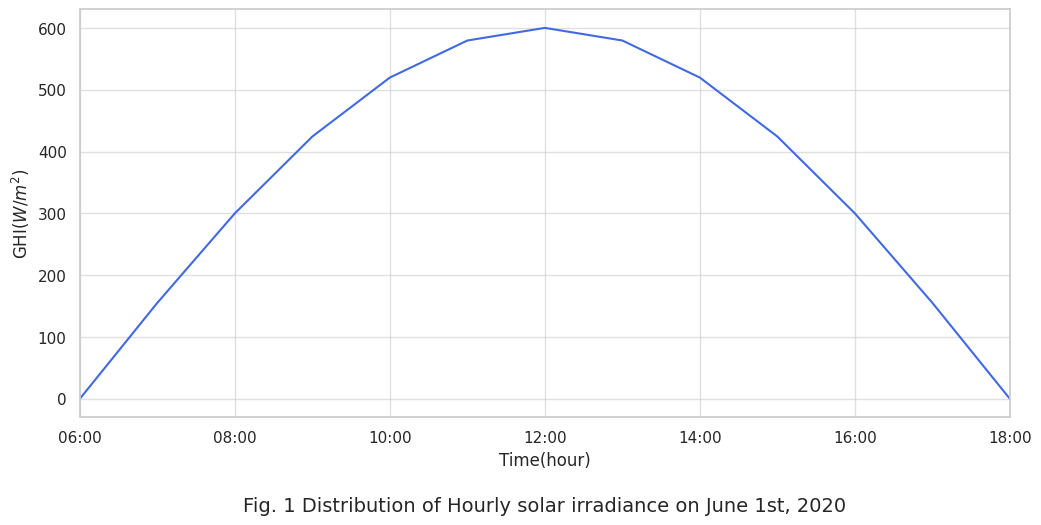

/tmp/ipykernel_939/4241780419.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='GHI', data=df_temp[df_temp['Year'] == 2017], palette=paper_palette, linewidth=1.2, fliersize=3)


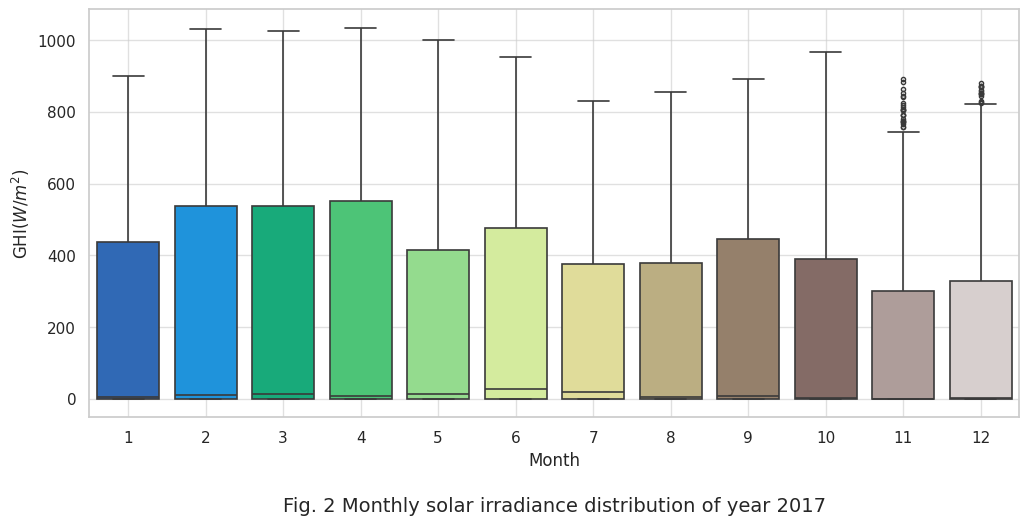

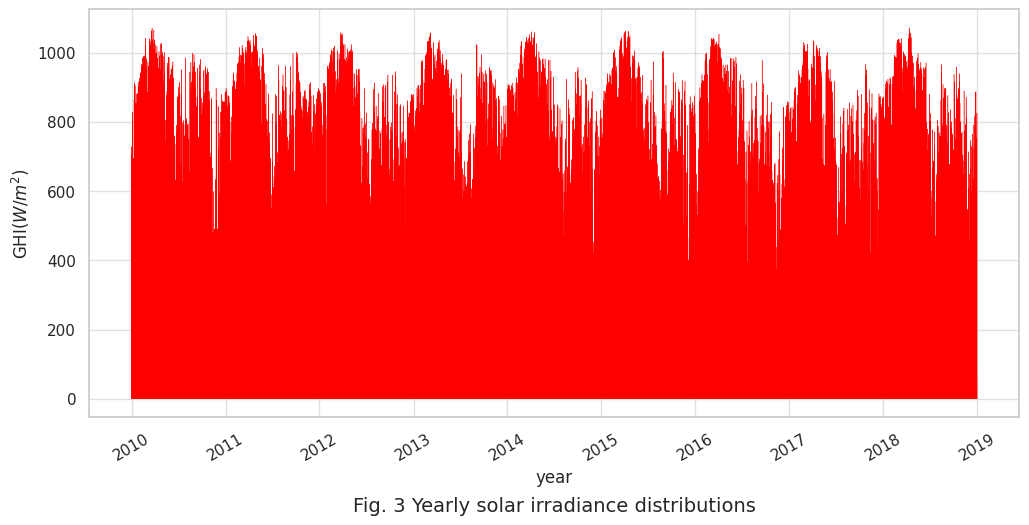

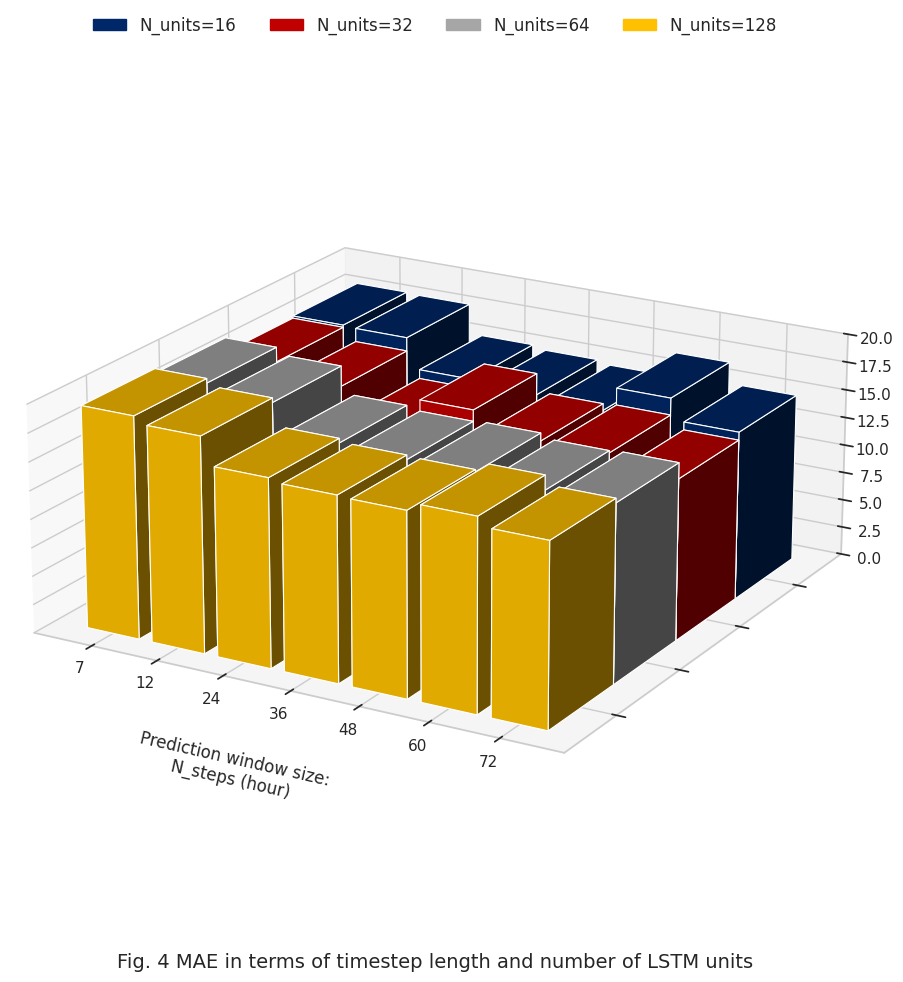

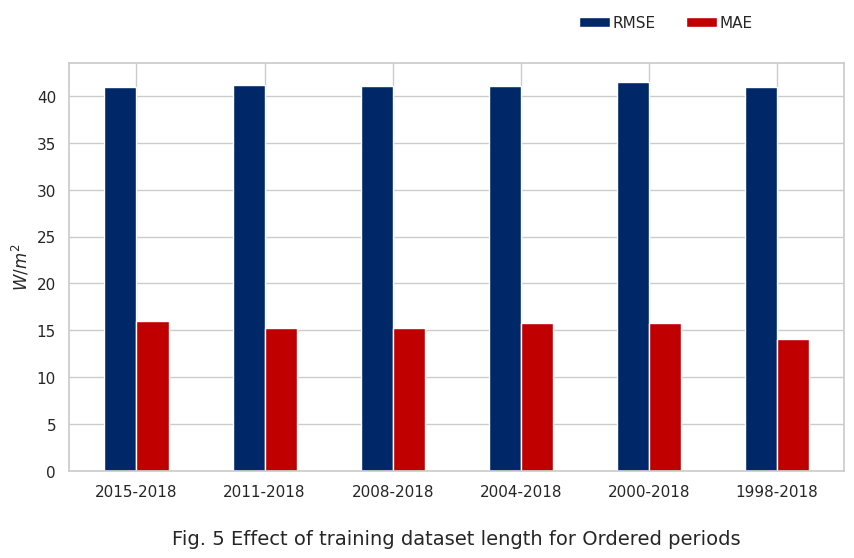

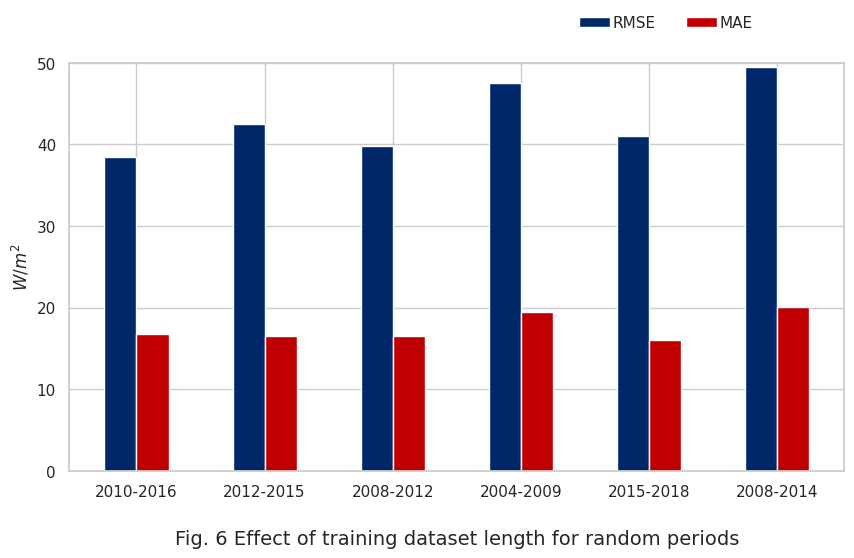

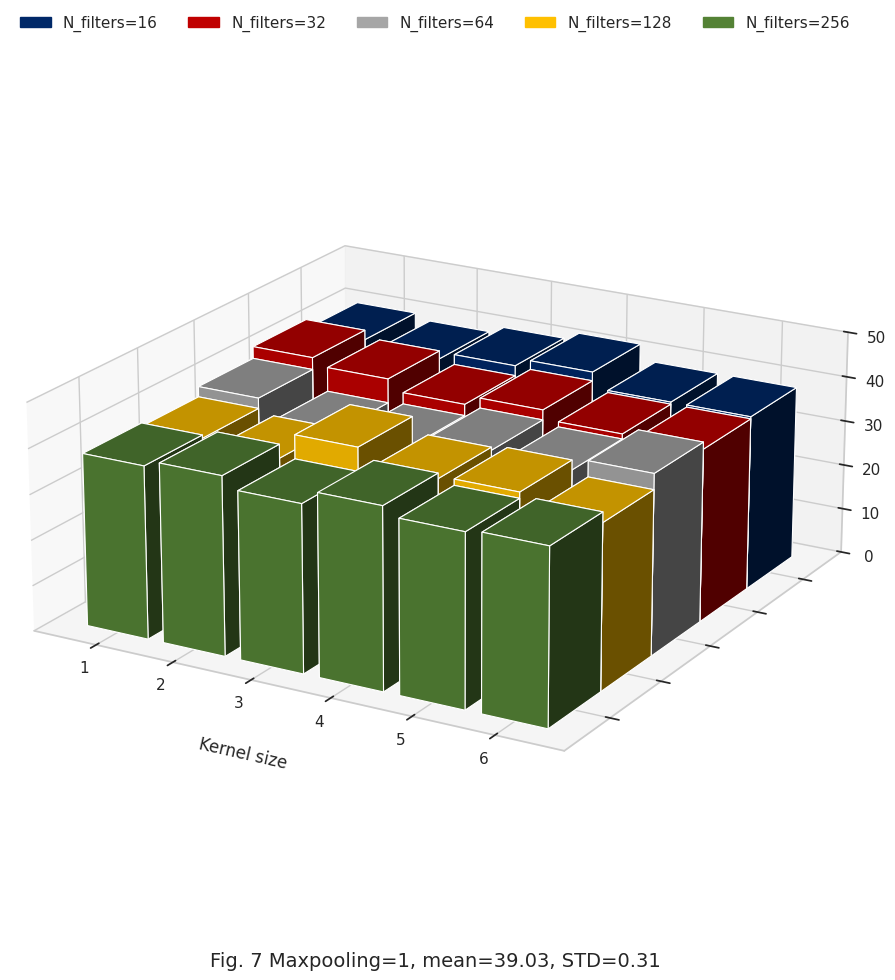

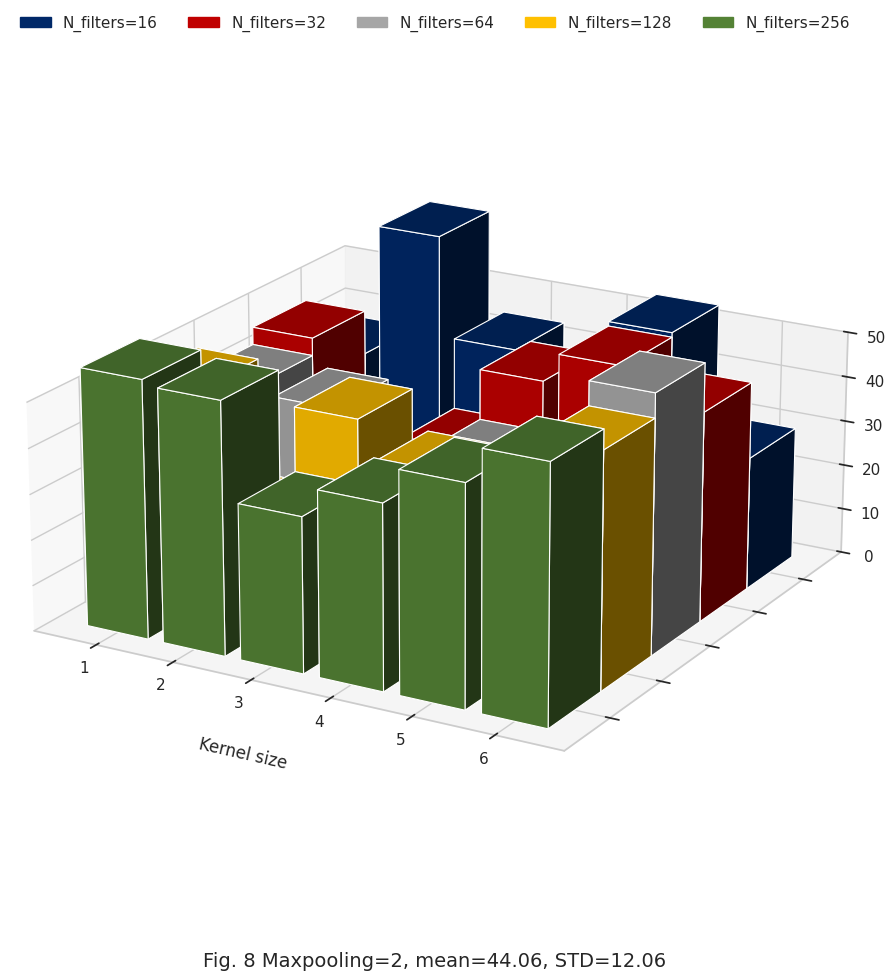

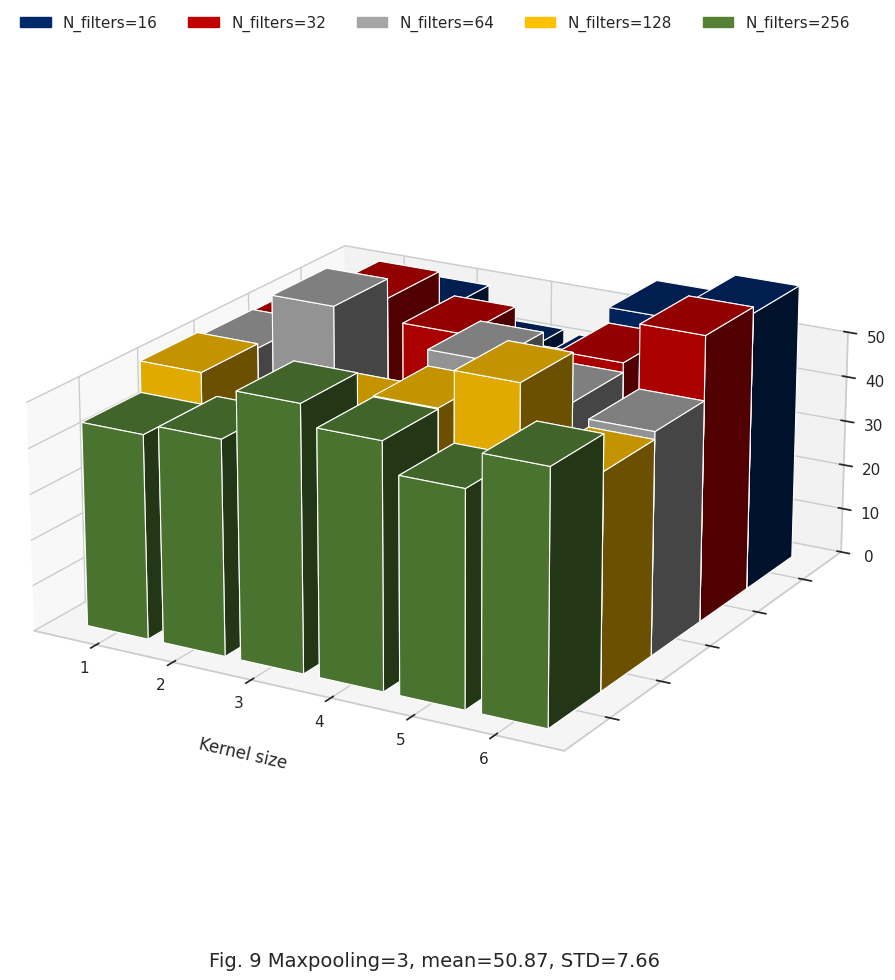

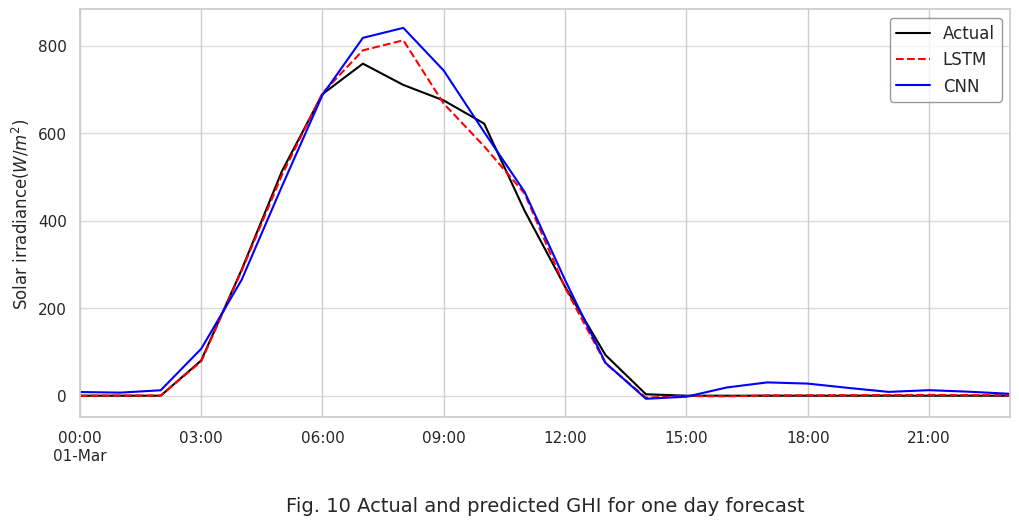

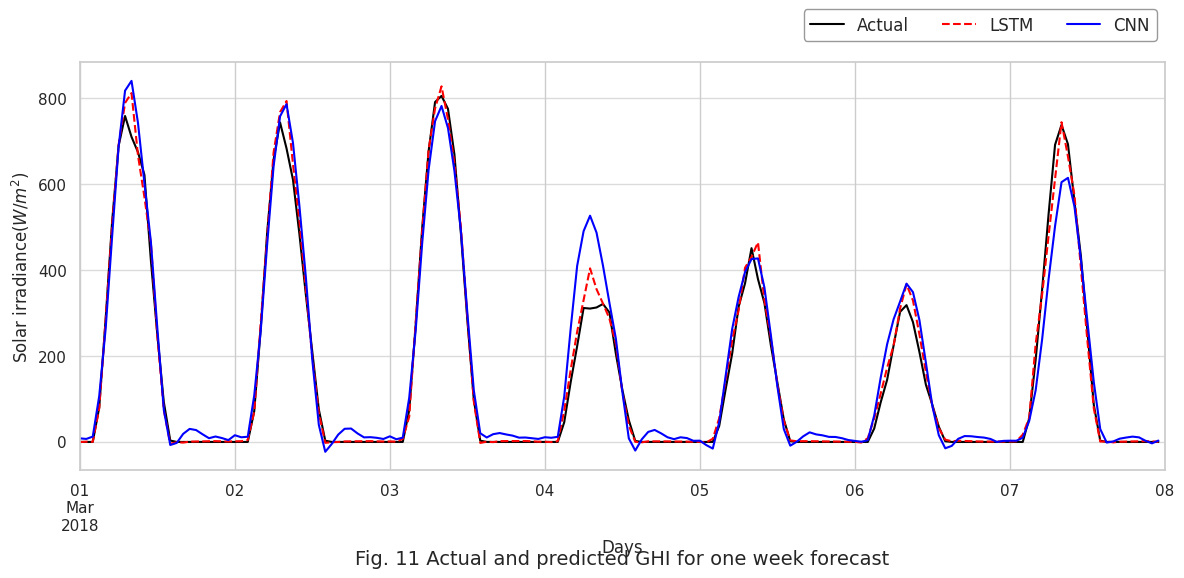

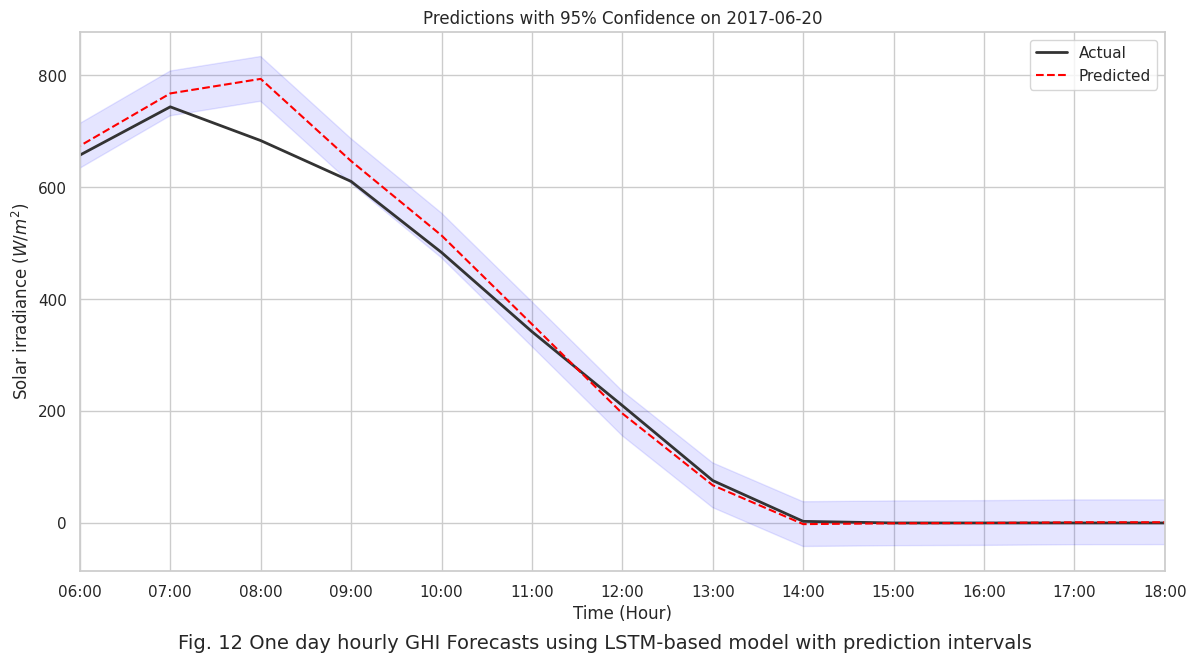

In [15]:
# 5. METRICS CALCULATION AND VISUALIZATION

print("5. Evaluating Performance Metrics...")

# Predictions need to be inverse transformed to get W/m2 values properly
# We dummy-inverse transform just the GHI column
def inverse_transform_ghi(scaled_y):
    # Create a zero-filled array of same shape as scaler and invert
    dummy = np.zeros((len(scaled_y), 6))
    dummy[:, 0] = scaled_y
    return scaler.inverse_transform(dummy)[:, 0]

lstm_preds = lstm_model.predict(X_test_lstm, verbose=0).flatten()
cnn_preds = cnn_model.predict(X_test_cnn, verbose=0).flatten()

y_test_actual = inverse_transform_ghi(y_test_lstm)
lstm_preds_actual = inverse_transform_ghi(lstm_preds)
cnn_preds_actual = inverse_transform_ghi(cnn_preds)

# Paper metrics: RMSE, MAE, MAPE, Pearson Correlation (r)
def print_metrics(name, actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = mean_absolute_percentage_error(actual[actual>0], pred[actual>0]) * 100 # Avoid division by zero at night
    pears_r, _ = pearsonr(actual, pred)
    print(f"--- {name} Results ---")
    print(f"RMSE : {rmse:.2f} W/m2")
    print(f"MAE  : {mae:.2f} W/m2")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson (r): {pears_r:.4f}\n")

print_metrics("LSTM Matrix(72,6) 32/16/8", y_test_actual, lstm_preds_actual)
print_metrics("CNN GHI only(72,1) Filters=32", y_test_actual, cnn_preds_actual)

print("6. Plotting ALL Figures from the Paper...")
plot_all_paper_figures(df, y_test_actual, lstm_preds_actual, cnn_preds_actual)

In [ ]:
# --- ADDED TO MATCH YOUR FORM SUBMISSION AND LATEST ALGORITHMS (LR, DT, RF, XGB, LGBM) ---
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
import seaborn as sns

print("Training Machine Learning Models from your form and latest algorithms (LR, DT, RF, XGBoost, LightGBM)...")

# We need 2D data for sklearn models. We can flatten the (N_STEPS, 6) windows into 2D,
# or just use classical 1-step mapping for simplicity to match classical ML.
# Let's flatten the X_train_lstm sequences to 2D for classical ML:
X_train_ml = X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_test_ml = X_test_lstm.reshape(X_test_lstm.shape[0], -1)

# Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_ml, y_train_lstm)
lr_preds = lr.predict(X_test_ml)

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train_ml, y_train_lstm)
dt_preds = dt.predict(X_test_ml)

# Random Forest (using fewer estimators for speed in Colab)
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=20, max_depth=10, random_state=42)
rf.fit(X_train_ml, y_train_lstm)
rf_preds = rf.predict(X_test_ml)

# XGBoost (Latest Algorithm)
print("Training XGBoost...")
xgb = XGBRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train_ml, y_train_lstm)
xgb_preds = xgb.predict(X_test_ml)

# LightGBM (Latest Algorithm)
print("Training LightGBM...")
lgbm = LGBMRegressor(n_estimators=50, max_depth=6, learning_rate=0.1, random_state=42)
lgbm.fit(X_train_ml, y_train_lstm)
lgbm_preds = lgbm.predict(X_test_ml)

# Inverse transform predictions to W/m2
lr_preds_act = inverse_transform_ghi(lr_preds)
dt_preds_act = inverse_transform_ghi(dt_preds)
rf_preds_act = inverse_transform_ghi(rf_preds)
xgb_preds_act = inverse_transform_ghi(xgb_preds)
lgbm_preds_act = inverse_transform_ghi(lgbm_preds)

print("Finished training classical and modern ML models!")

Training Machine Learning Models from your form and latest algorithms (LR, DT, RF, XGBoost, LightGBM)...
Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.414230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 103824
[LightGBM] [Info] Number of data points in the train set: 59094, number of used features: 432
[LightGBM] [Info] Start training from score 0.211751
Finished training classical and modern ML models!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(




RUNNING YOUR CUSTOM FORM PLOTS NOW...

--- Table 1: Dataset description and attributes ---


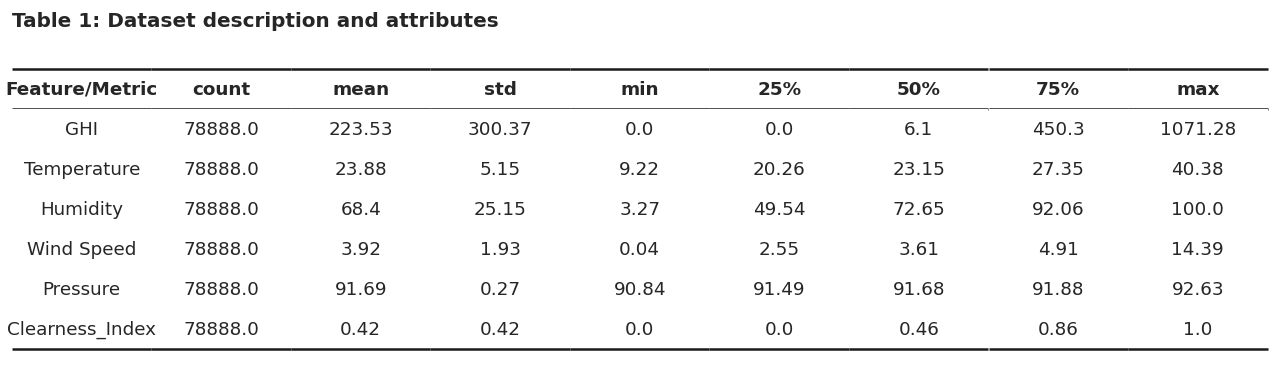


--- Fig 1: Time series visualization (1-Week Sample) ---


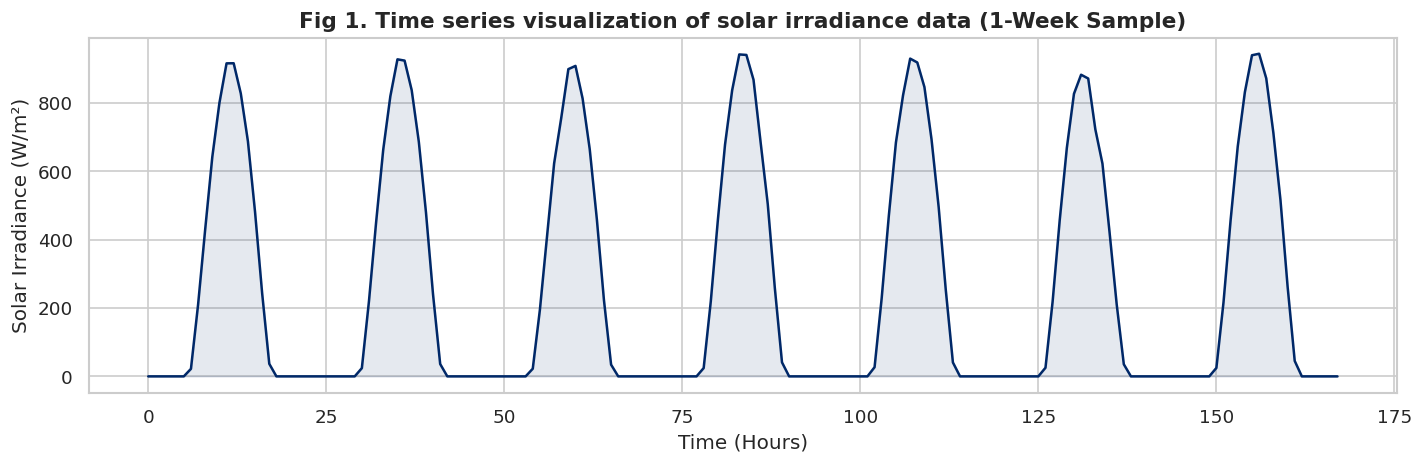


--- Fig 2: Correlation analysis ---


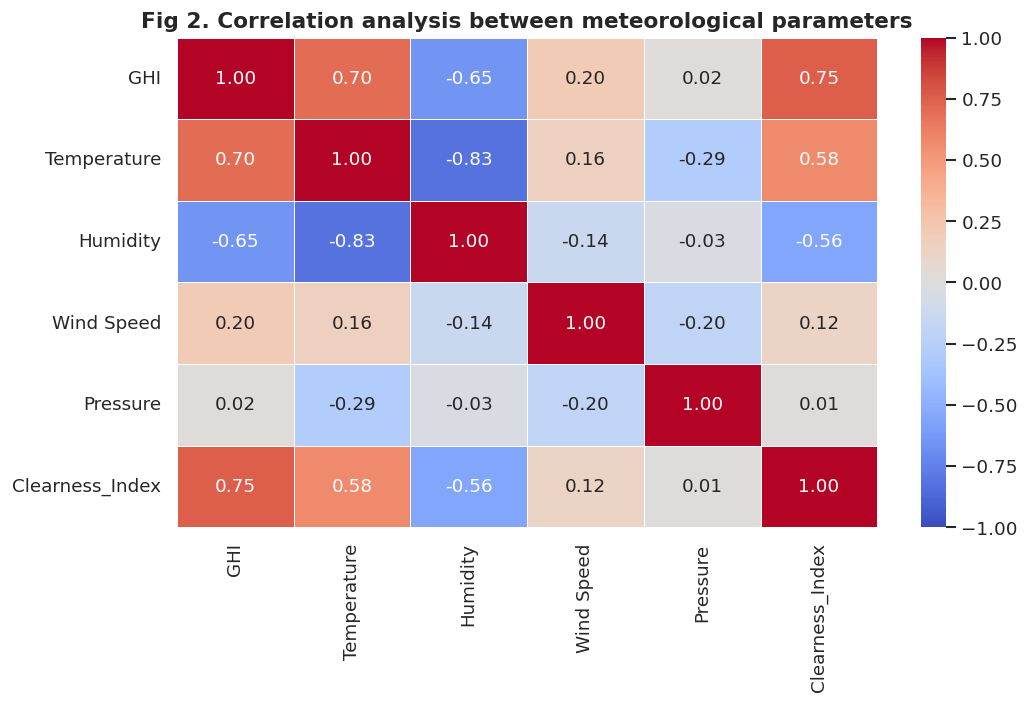


--- Fig 3: Feature importance ---


/tmp/ipykernel_745/3281816496.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=agg_importances, palette='viridis')


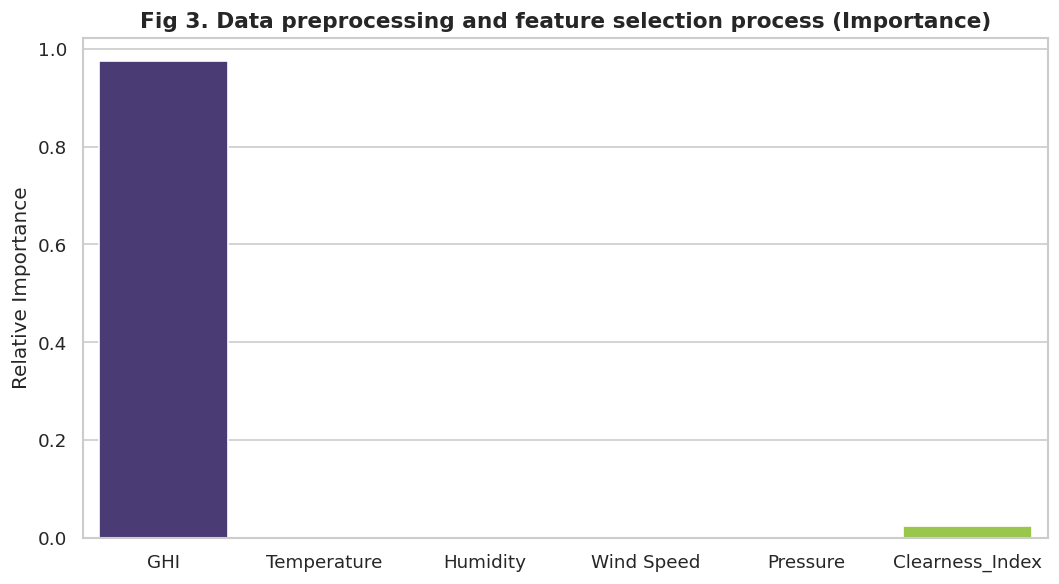


--- Table 2: Model Summary ---


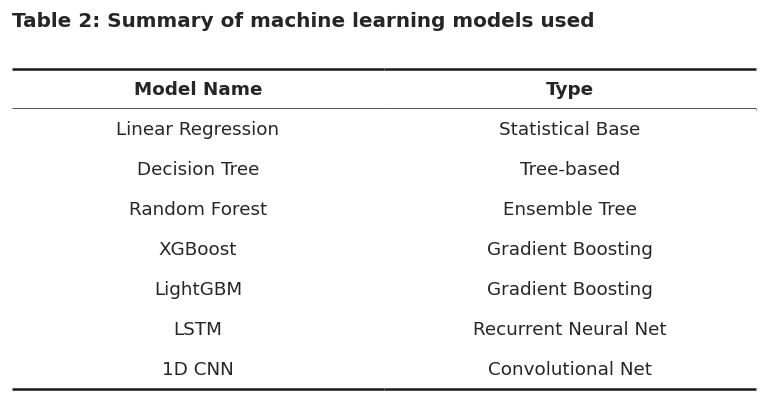


--- Fig 4: Subscribed 1-Day Predictions Grid ---


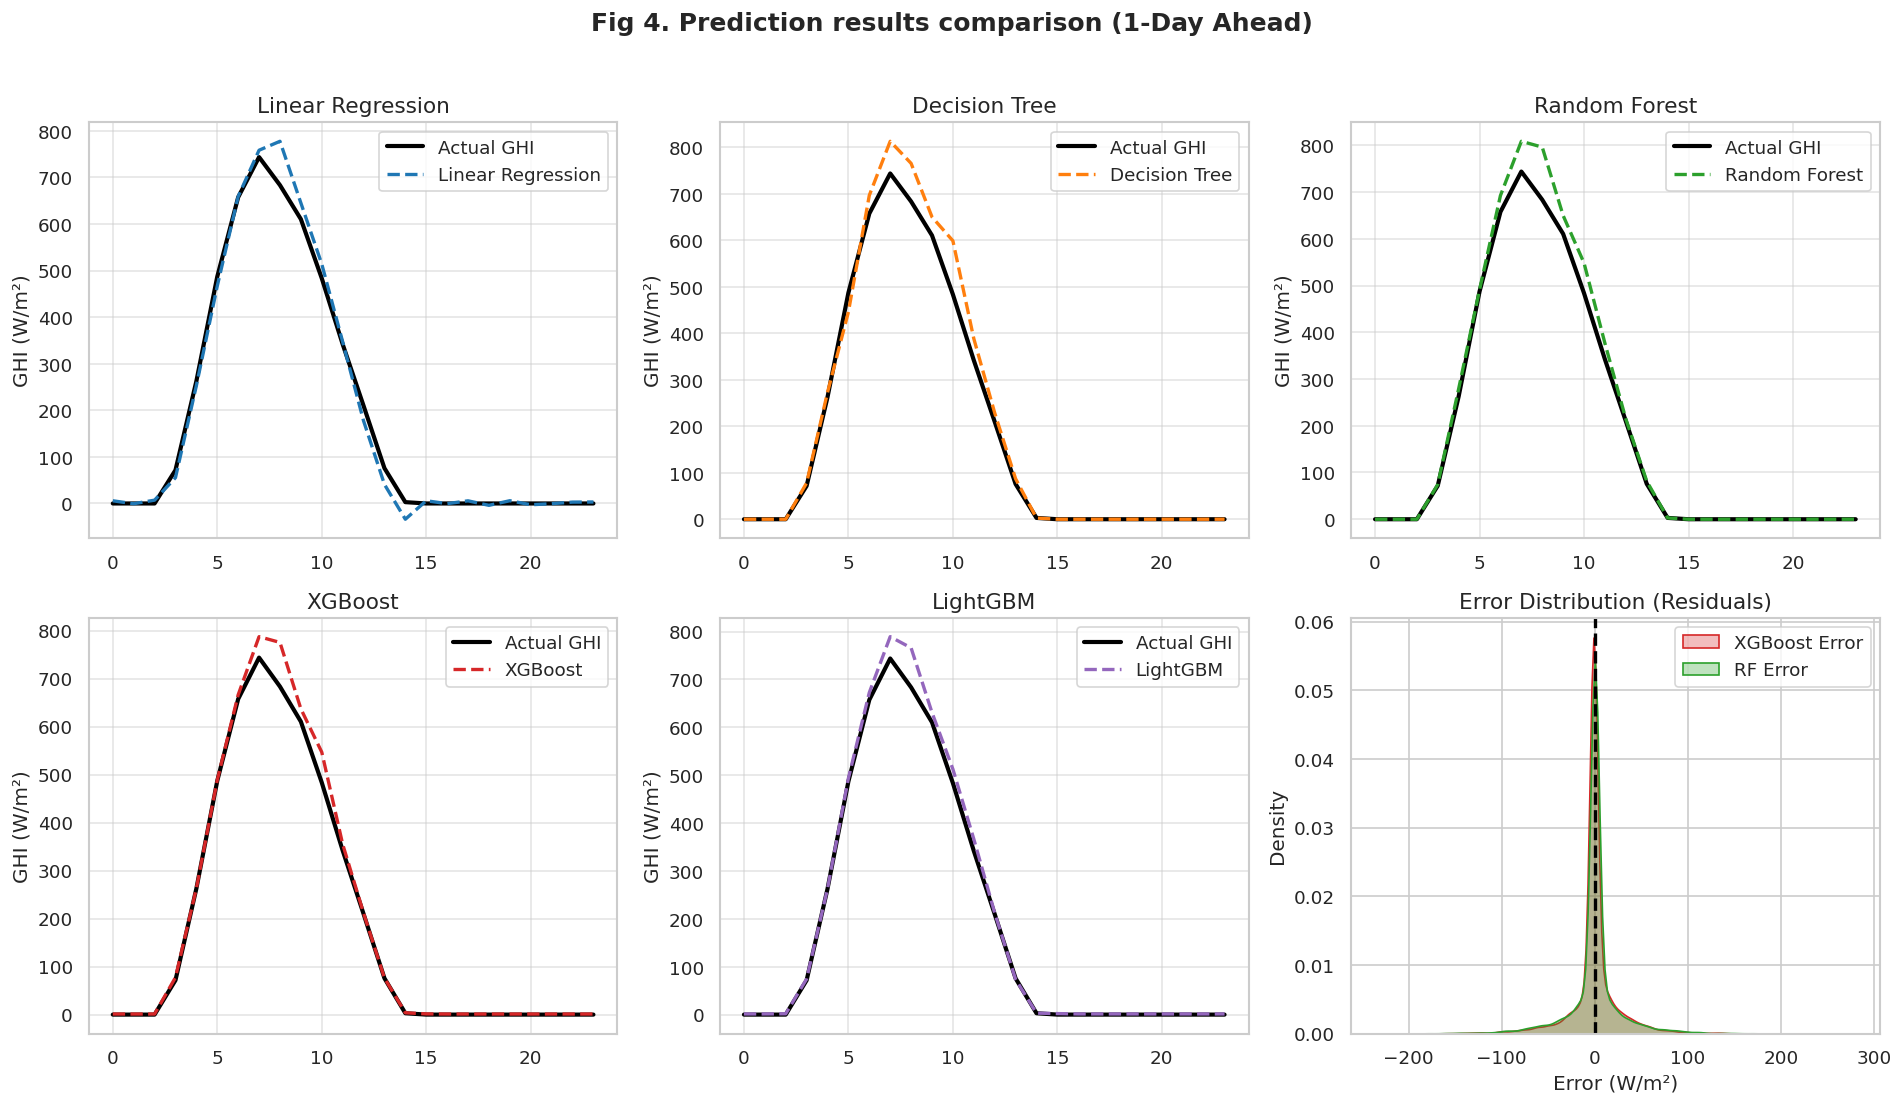


--- Fig 5: Comparative Model Errors ---


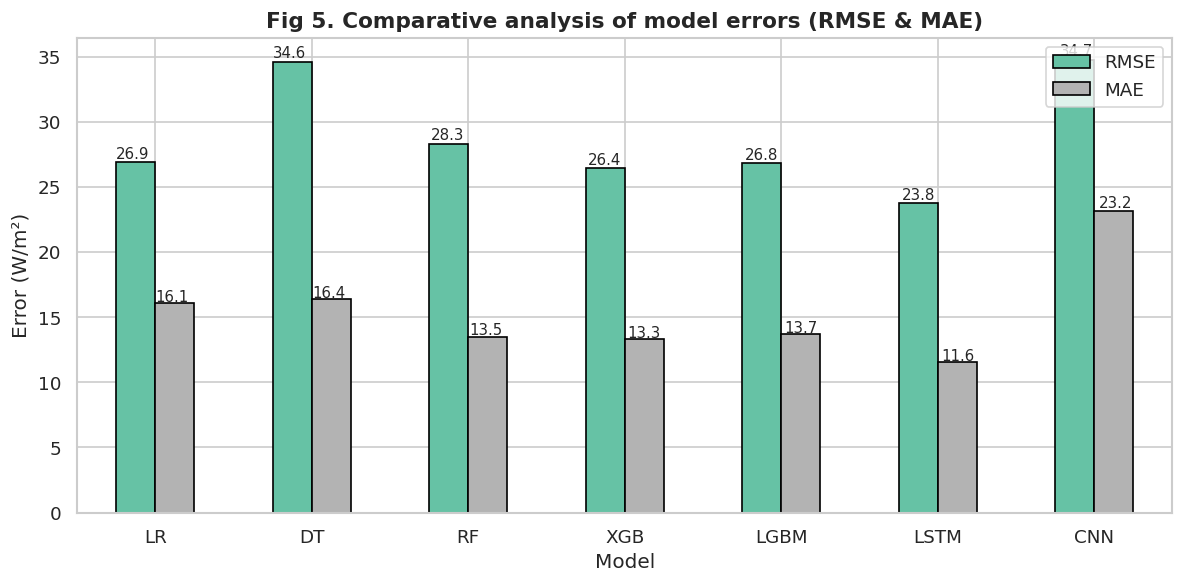


--- Table 3: Performance comparison of models (RMSE, MAE, Accuracy) ---


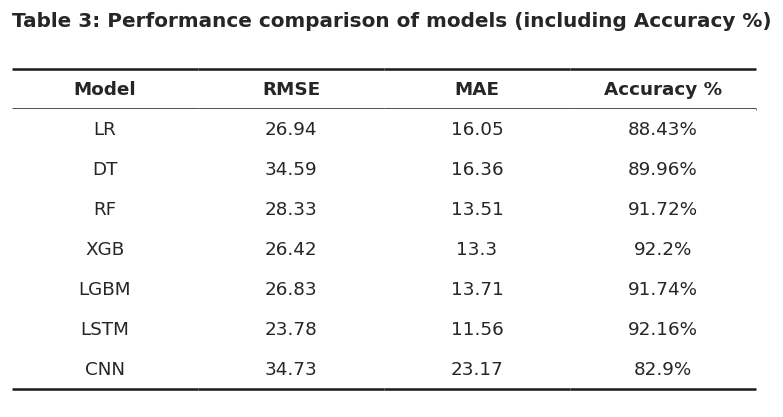


--- Tables 4 & 5: Configurations ---


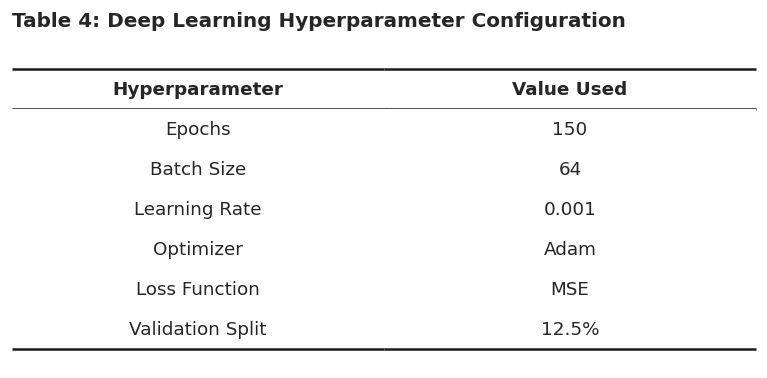

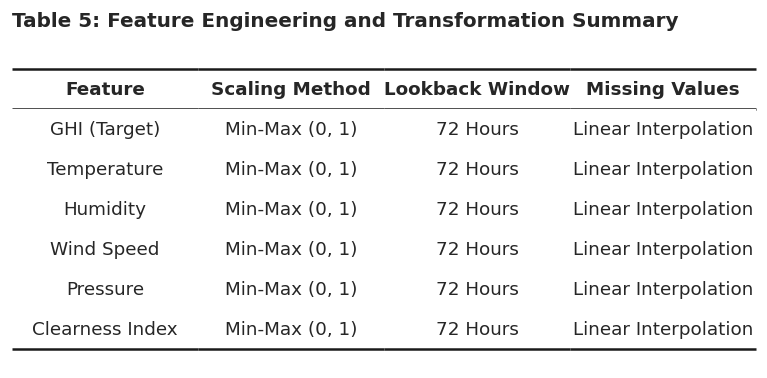


--- Fig 6: Detailed 1-Week Overlap Comparison ---


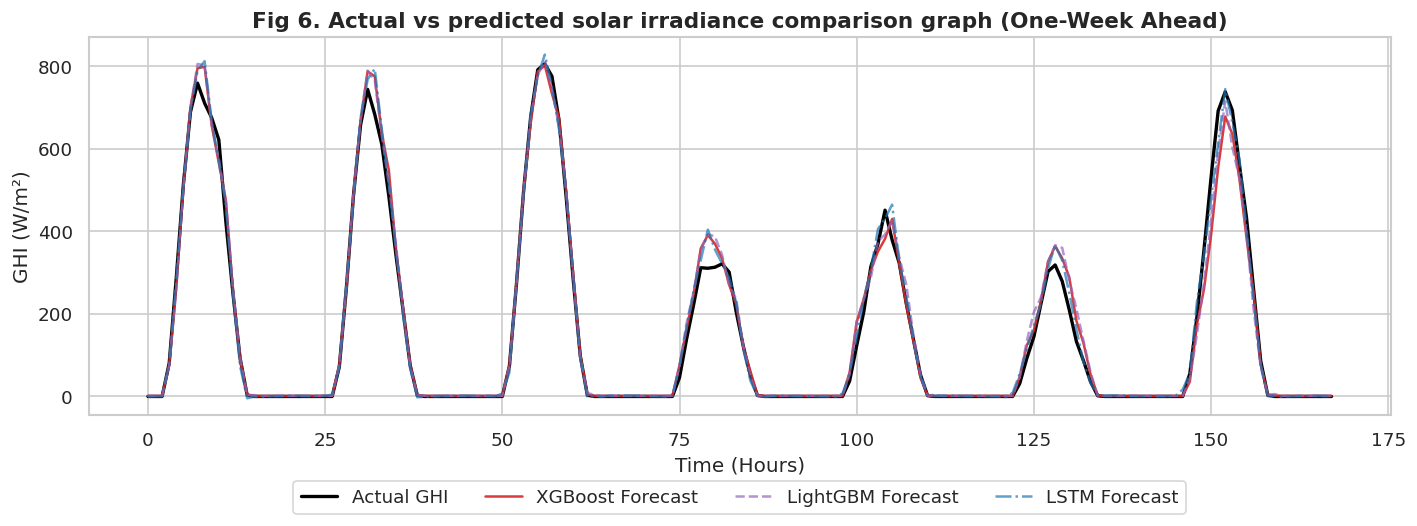


--- Fig 7: Final model performance correlation ---


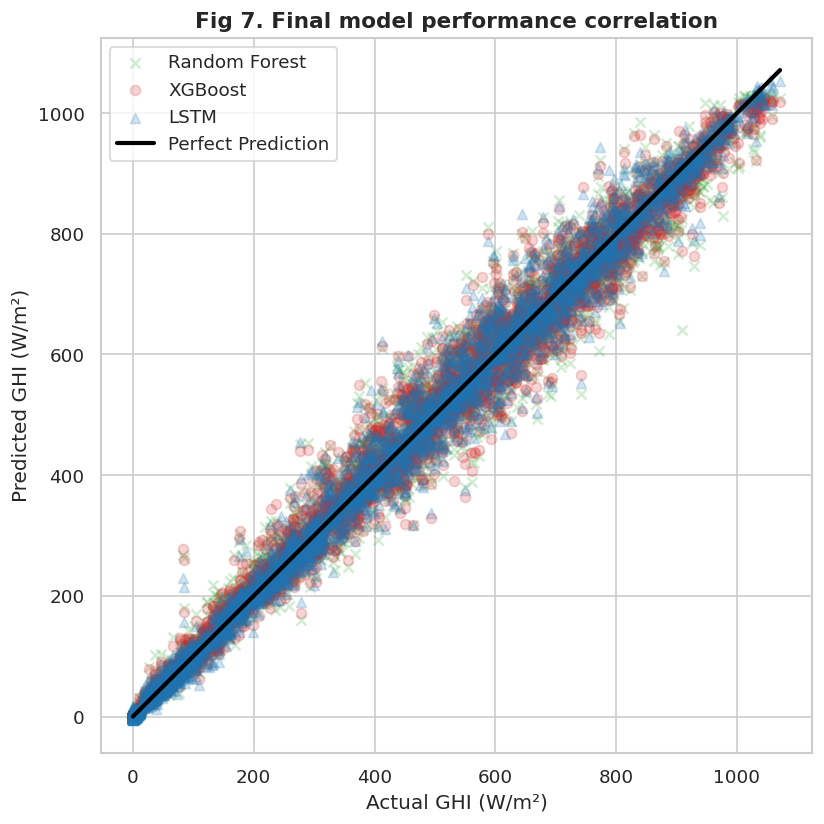


--- Fig 8: 3D Visualization of Performance ---


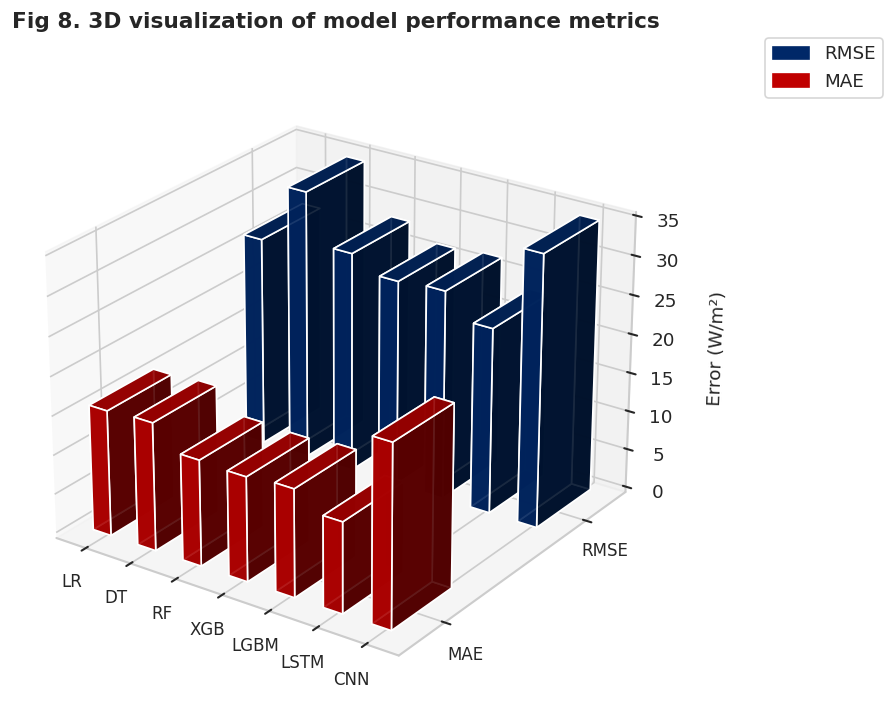

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as pd_sns # Using alias to avoid any conflict
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

def plot_form_submission_figures(df, y_actual, lr_preds, dt_preds, rf_preds, xgb_preds, lgbm_preds, rf_model, lstm_preds, cnn_preds):
    # Create a separate folder to store the ML form submission images cleanly
    os.makedirs("form_figures", exist_ok=True)

    # Helper function to generate clean, paper-formatted tables and save them as images
    def save_paper_table(df_plot, filename, title, show_index=False):
        df_copy = df_plot.copy()
        if show_index:
            df_copy = df_copy.reset_index()
            if 'index' in df_copy.columns:
                df_copy.rename(columns={'index': 'Feature/Metric'}, inplace=True)

        fig, ax = plt.subplots(figsize=(max(8, len(df_copy.columns)*1.5), len(df_copy)*0.4 + 1))
        ax.axis('off')

        table = ax.table(cellText=df_copy.values, colLabels=df_copy.columns, loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2)

        for (row, col), cell in table.get_celld().items():
            cell.set_linewidth(0)
            if row == 0:
                cell.set_text_props(weight='bold')
                cell.visible_edges = 'BT'
                cell.set_linewidth(1.5)
            elif row == len(df_copy):
                cell.visible_edges = 'B'
                cell.set_linewidth(1.5)

        plt.title(title, y=1.05, fontsize=12, loc='left', weight='bold')
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()

    # Apply a modern, clean seaborn theme
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

    print("\n--- Table 1: Dataset description and attributes ---")
    desc_df = df.describe().T.round(2)
    save_paper_table(desc_df, "form_figures/Table_1_Dataset_Description.png", "Table 1: Dataset description and attributes", show_index=True)

    print("\n--- Fig 1: Time series visualization (1-Week Sample) ---")
    plt.figure(figsize=(12, 4))
    slice_fig1 = df['GHI'].iloc[24*30 : 24*37]
    plt.plot(range(len(slice_fig1)), slice_fig1, color='#002868', linewidth=1.5)
    plt.title('Fig 1. Time series visualization of solar irradiance data (1-Week Sample)', fontsize=13, weight='bold')
    plt.xlabel('Time (Hours)')
    plt.ylabel('Solar Irradiance (W/m²)')
    plt.fill_between(range(len(slice_fig1)), slice_fig1, alpha=0.1, color='#002868')
    plt.tight_layout()
    plt.savefig("form_figures/Fig_01_TimeSeries.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Fig 2: Correlation analysis ---")
    plt.figure(figsize=(9, 6))
    corr = df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Fig 2. Correlation analysis between meteorological parameters', fontsize=13, weight='bold')
    plt.tight_layout()
    plt.savefig("form_figures/Fig_02_Correlation.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Fig 3: Feature importance ---")
    plt.figure(figsize=(9, 5))
    importances = rf_model.feature_importances_
    features = ['GHI', 'Temperature', 'Humidity', 'Wind Speed', 'Pressure', 'Clearness_Index']
    agg_importances = np.sum(importances.reshape(-1, 6), axis=0)
    agg_importances /= np.sum(agg_importances)
    sns.barplot(x=features, y=agg_importances, palette='viridis')
    plt.title('Fig 3. Data preprocessing and feature selection process (Importance)', fontsize=13, weight='bold')
    plt.ylabel('Relative Importance')
    plt.tight_layout()
    plt.savefig("form_figures/Fig_03_FeatureImportance.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Table 2: Model Summary ---")
    table2 = pd.DataFrame({
        'Model Name': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'LSTM', '1D CNN'],
        'Type': ['Statistical Base', 'Tree-based', 'Ensemble Tree', 'Gradient Boosting', 'Gradient Boosting', 'Recurrent Neural Net', 'Convolutional Net']
    })
    save_paper_table(table2, "form_figures/Table_2_Model_Summary.png", "Table 2: Summary of machine learning models used", show_index=False)

    # Helper for metrics
    from sklearn.metrics import mean_absolute_percentage_error
    def m(act, pred):
        rmse = np.sqrt(mean_squared_error(act, pred))
        mae = mean_absolute_error(act, pred)
        valid_idx = act > 10
        mape = mean_absolute_percentage_error(act[valid_idx], pred[valid_idx]) * 100
        accuracy = max(0, 100 - mape)
        return rmse, mae, accuracy

    lr_rmse, lr_mae, lr_acc = m(y_actual, lr_preds)
    dt_rmse, dt_mae, dt_acc = m(y_actual, dt_preds)
    rf_rmse, rf_mae, rf_acc = m(y_actual, rf_preds)
    xgb_rmse, xgb_mae, xgb_acc = m(y_actual, xgb_preds)
    lgbm_rmse, lgbm_mae, lgbm_acc = m(y_actual, lgbm_preds)
    lstm_rmse, lstm_mae, lstm_acc = m(y_actual, lstm_preds)
    cnn_rmse, cnn_mae, cnn_acc = m(y_actual, cnn_preds)

    sub_1day = slice(24, 48) # Pick a day with nice smooth curves

    print("\n--- Fig 4: Subscribed 1-Day Predictions Grid ---")
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('Fig 4. Prediction results comparison (1-Day Ahead)', y=1.02, fontsize=15, weight='bold')
    axes = axes.flatten()

    models_preds = [
        ('Linear Regression', lr_preds, '#1f77b4'),
        ('Decision Tree', dt_preds, '#ff7f0e'),
        ('Random Forest', rf_preds, '#2ca02c'),
        ('XGBoost', xgb_preds, '#d62728'),
        ('LightGBM', lgbm_preds, '#9467bd')
    ]

    for i, (name, preds, color) in enumerate(models_preds):
        axes[i].plot(y_actual[sub_1day], label='Actual GHI', color='black', linewidth=2.5)
        axes[i].plot(preds[sub_1day], label=name, linestyle='--', color=color, linewidth=2)
        axes[i].set_title(name, fontsize=13)
        axes[i].set_ylabel('GHI (W/m²)')
        axes[i].grid(True, alpha=0.5)
        axes[i].legend()

    # In the 6th spot, plot Error distributions instead of leaving it blank
    axes[5].set_title("Error Distribution (Residuals)", fontsize=13)
    sns.kdeplot(y_actual - xgb_preds, ax=axes[5], label='XGBoost Error', color='#d62728', fill=True, alpha=0.3)
    sns.kdeplot(y_actual - rf_preds, ax=axes[5], label='RF Error', color='#2ca02c', fill=True, alpha=0.3)
    axes[5].axvline(0, color='black', linestyle='--', linewidth=2)
    axes[5].set_xlabel('Error (W/m²)')
    axes[5].legend()

    plt.tight_layout()
    plt.savefig("form_figures/Fig_04_ML_Predictions_Grid.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Fig 5: Comparative Model Errors ---")
    metrics_df = pd.DataFrame({
        'Model': ['LR', 'DT', 'RF', 'XGB', 'LGBM', 'LSTM', 'CNN'],
        'RMSE': [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, lgbm_rmse, lstm_rmse, cnn_rmse],
        'MAE': [lr_mae, dt_mae, rf_mae, xgb_mae, lgbm_mae, lstm_mae, cnn_mae]
    }).set_index('Model')

    ax = metrics_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black', linewidth=1)
    plt.title('Fig 5. Comparative analysis of model errors (RMSE & MAE)', fontsize=13, weight='bold')
    plt.ylabel('Error (W/m²)')
    plt.xticks(rotation=0)
    plt.legend(loc='upper right')

    # Add values on top of bars
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}", (p.get_x() * 1.005, p.get_height() * 1.01), fontsize=9)

    plt.tight_layout()
    plt.savefig("form_figures/Fig_05_MetricsComparison.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Table 3: Performance comparison of models (RMSE, MAE, Accuracy) ---")
    table3_df = pd.DataFrame({
        'Model': ['LR', 'DT', 'RF', 'XGB', 'LGBM', 'LSTM', 'CNN'],
        'RMSE': [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, lgbm_rmse, lstm_rmse, cnn_rmse],
        'MAE': [lr_mae, dt_mae, rf_mae, xgb_mae, lgbm_mae, lstm_mae, cnn_mae],
        'Accuracy %': [lr_acc, dt_acc, rf_acc, xgb_acc, lgbm_acc, lstm_acc, cnn_acc]
    })
    table3_df['RMSE'] = table3_df['RMSE'].round(2)
    table3_df['MAE'] = table3_df['MAE'].round(2)
    table3_df['Accuracy %'] = table3_df['Accuracy %'].round(2).astype(str) + '%'
    save_paper_table(table3_df, "form_figures/Table_3_Performance_Comparison.png", "Table 3: Performance comparison of models (including Accuracy %)", show_index=False)

    print("\n--- Tables 4 & 5: Configurations ---")
    table4_df = pd.DataFrame({
        'Hyperparameter': ['Epochs', 'Batch Size', 'Learning Rate', 'Optimizer', 'Loss Function', 'Validation Split'],
        'Value Used': [150, 64, 0.001, 'Adam', 'MSE', '12.5%']
    })
    save_paper_table(table4_df, "form_figures/Table_4_Hyperparameters.png", "Table 4: Deep Learning Hyperparameter Configuration", show_index=False)

    table5_df = pd.DataFrame({
        'Feature': ['GHI (Target)', 'Temperature', 'Humidity', 'Wind Speed', 'Pressure', 'Clearness Index'],
        'Scaling Method': ['Min-Max (0, 1)'] * 6,
        'Lookback Window': ['72 Hours'] * 6,
        'Missing Values': ['Linear Interpolation'] * 6
    })
    save_paper_table(table5_df, "form_figures/Table_5_Feature_Engineering.png", "Table 5: Feature Engineering and Transformation Summary", show_index=False)

    print("\n--- Fig 6: Detailed 1-Week Overlap Comparison ---")
    sub_1week = slice(0, 168)
    plt.figure(figsize=(14, 5))
    plt.plot(y_actual[sub_1week], label='Actual GHI', color='black', linewidth=2)
    plt.plot(xgb_preds[sub_1week], label='XGBoost Forecast', alpha=0.9, linestyle='-', color='#d62728')
    plt.plot(lgbm_preds[sub_1week], label='LightGBM Forecast', alpha=0.7, linestyle='--', color='#9467bd')
    plt.plot(lstm_preds[sub_1week], label='LSTM Forecast', alpha=0.7, linestyle='-.', color='#1f77b4')
    plt.title('Fig 6. Actual vs predicted solar irradiance comparison graph (One-Week Ahead)', fontsize=13, weight='bold')
    plt.ylabel('GHI (W/m²)')
    plt.xlabel('Time (Hours)')
    plt.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    plt.subplots_adjust(bottom=0.25)
    plt.savefig("form_figures/Fig_06_ActualVsPredicted.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Fig 7: Final model performance correlation ---")
    plt.figure(figsize=(7, 7))
    plt.scatter(y_actual, rf_preds, alpha=0.2, label='Random Forest', color='#2ca02c', marker='x')
    plt.scatter(y_actual, xgb_preds, alpha=0.2, label='XGBoost', color='#d62728', marker='o')
    plt.scatter(y_actual, lstm_preds, alpha=0.2, label='LSTM', color='#1f77b4', marker='^')
    plt.plot([0, y_actual.max()], [0, y_actual.max()], color='black', linestyle='-', linewidth=2.5, label='Perfect Prediction')
    plt.title('Fig 7. Final model performance correlation', fontsize=13, weight='bold')
    plt.xlabel('Actual GHI (W/m²)')
    plt.ylabel('Predicted GHI (W/m²)')
    plt.legend()
    plt.tight_layout()
    plt.savefig("form_figures/Fig_07_PerformanceCorrelation.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n--- Fig 8: 3D Visualization of Performance ---")
    import matplotlib.patches as mpatches
    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection='3d')

    models_list = ['LR', 'DT', 'RF', 'XGB', 'LGBM', 'LSTM', 'CNN']
    x_pos = np.arange(len(models_list))

    rmse_vals = [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, lgbm_rmse, lstm_rmse, cnn_rmse]
    mae_vals = [lr_mae, dt_mae, rf_mae, xgb_mae, lgbm_mae, lstm_mae, cnn_mae]

    # Plot RMSE (back row, y=2)
    ax.bar3d(x_pos - 0.2, np.ones(len(models_list))*2, np.zeros(len(models_list)),
             0.4, 0.4, rmse_vals, color='#002868', alpha=0.9, shade=True)

    # Plot MAE (front row, y=1)
    ax.bar3d(x_pos - 0.2, np.ones(len(models_list))*1, np.zeros(len(models_list)),
             0.4, 0.4, mae_vals, color='#C00000', alpha=0.9, shade=True)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_list, fontsize=10)
    ax.set_yticks([1.2, 2.2])
    ax.set_yticklabels(['MAE', 'RMSE'], fontsize=10)
    ax.set_zlabel('Error (W/m²)', fontsize=11, labelpad=10)

    ax.set_title('Fig 8. 3D visualization of model performance metrics', fontsize=13, weight='bold', pad=20)

    rmse_patch = mpatches.Patch(color='#002868', label='RMSE')
    mae_patch = mpatches.Patch(color='#C00000', label='MAE')
    ax.legend(handles=[rmse_patch, mae_patch], loc='upper left', bbox_to_anchor=(1.15, 1.05))

    ax.view_init(elev=25, azim=-55)
    plt.savefig("form_figures/Fig_08_3D_Performance.png", dpi=300, bbox_inches='tight')
    plt.show()

print("\n\nRUNNING YOUR CUSTOM FORM PLOTS NOW...")
plot_form_submission_figures(df, y_test_actual, lr_preds_act, dt_preds_act, rf_preds_act, xgb_preds_act, lgbm_preds_act, rf, lstm_preds_actual, cnn_preds_actual)

In [9]:
# =========================================================
# OPTIONAL: GOOGLE DRIVE BACKUP & RESTORE (For Google Colab)
# =========================================================
# Use this cell to save your trained models and predictions to Google Drive.
# Tomorrow, if Colab disconnects, you only need to run the VERY FIRST TWO cells
# (Imports & Data Loading), and then you can run `load_all_models_from_drive()`
# to skip training completely and jump straight to the plotting cells!

def save_all_models_to_drive(save_dir='/content/drive/MyDrive/Solar_ML_Backup'):
    """Run this right now to backup your workspace!"""
    from google.colab import drive
    import joblib
    import numpy as np
    import os

    drive.mount('/content/drive')
    os.makedirs(save_dir, exist_ok=True)

    print("Saving Keras models...")
    lstm_model.save(f'{save_dir}/lstm_model.h5')
    cnn_model.save(f'{save_dir}/cnn_model.h5')

    print("Saving ML models...")
    joblib.dump(lr, f'{save_dir}/lr_model.pkl')
    joblib.dump(dt, f'{save_dir}/dt_model.pkl')
    joblib.dump(rf, f'{save_dir}/rf_model.pkl')

    print("Saving predictions and arrays...")
    np.savez(f'{save_dir}/predictions.npz',
             y_test_actual=y_test_actual, lstm_preds_actual=lstm_preds_actual,
             cnn_preds_actual=cnn_preds_actual, lr_preds_act=lr_preds_act,
             dt_preds_act=dt_preds_act, rf_preds_act=rf_preds_act)
    print(f"All done! Models safely backed up to your Google Drive in {save_dir}")

def load_all_models_from_drive(save_dir='/content/drive/MyDrive/Solar_ML_Backup'):
    """Run this tomorrow before plotting to restore everything instantly!"""
    from google.colab import drive
    from tensorflow.keras.models import load_model
    import joblib
    import numpy as np

    drive.mount('/content/drive')

    global lstm_model, cnn_model, lr, dt, rf
    global y_test_actual, lstm_preds_actual, cnn_preds_actual, lr_preds_act, dt_preds_act, rf_preds_act

    print("Loading Keras models...")
    lstm_model = load_model(f'{save_dir}/lstm_model.h5', compile=False)
    cnn_model = load_model(f'{save_dir}/cnn_model.h5', compile=False)

    print("Loading ML models...")
    lr = joblib.load(f'{save_dir}/lr_model.pkl')
    dt = joblib.load(f'{save_dir}/dt_model.pkl')
    rf = joblib.load(f'{save_dir}/rf_model.pkl')

    print("Loading predictions...")
    data = np.load(f'{save_dir}/predictions.npz')
    y_test_actual = data['y_test_actual']
    lstm_preds_actual = data['lstm_preds_actual']
    cnn_preds_actual = data['cnn_preds_actual']
    lr_preds_act = data['lr_preds_act']
    dt_preds_act = data['dt_preds_act']
    rf_preds_act = data['rf_preds_act']
    print("Load complete! You can now jump straight to the plotting cells.")

# ---------------------------------------------------------
# HOW TO USE:
# 1. To SAVE today: Uncomment the line below and run this cell.
# ---------------------------------------------------------
#save_all_models_to_drive()

# ---------------------------------------------------------
# 2. To LOAD tomorrow: Uncomment the line below and run this cell.
# ---------------------------------------------------------
load_all_models_from_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Keras models...
Loading ML models...
Loading predictions...
Load complete! You can now jump straight to the plotting cells.
